In [1]:
!pip install -U 'skorch[pytorch]' && pip install -q -U faiss-gpu-cu12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 33.4 MB/s eta 0:00:00


In [2]:
import os
import torch
import numpy as np, pandas as pd, random
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.notebook import tqdm
from time import time, sleep
import itertools

import sklearn
from sklearn.frozen import FrozenEstimator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import KBinsDiscretizer, TargetEncoder
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, log_loss, ConfusionMatrixDisplay, RocCurveDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [3]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Configuration --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [4]:
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(seed=CFG['SEED'])

## Load Data

In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e6/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")

    ORIG_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/'
    orig = pd.read_csv(ORIG_PATH+'star_classification.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e6 | Stellar Class/_stellar_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'star_classification.csv')#.drop(['customerID'], axis=1)

## =================================================================================

ID = 'id'
TARGET = train.columns[-1]

CATS   = ['spectral_type', 'galaxy_population']
NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping = {c: i for i, c in enumerate(train[TARGET].unique())}
r_mapping = {i: c for i, c in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in [('Train', train), ('Test', test), ('Original', orig)]:
    print(f"{name} shape: {df.shape}")

print(f"\nTotal nums: {len(NUMS)}")
print(f"Total cats: {len(CATS)}")
print(f"Total base: {len(BASE)}")

Train shape: (577347, 12)
Test shape: (247435, 11)
Original shape: (100000, 18)

Total nums: 8
Total cats: 2
Total base: 10


In [6]:
## -- ['spectral_type', 'galaxy_population'] derivation for original data --
def spectral_type(g, r):
    return pd.cut(
        r-g, 
        [-np.inf, -1, -0.5, 0, np.inf],
        labels=['M', 'G/K', 'A/F', 'O/B']
    ).astype(str)

def galaxy_population(u, r):
    return pd.cut(
        u-r, 
        [-np.inf, 2.2, np.inf],
        labels=['Blue_Cloud', 'Red_Sequence']
    ).astype(str)

orig['spectral_type'] = spectral_type(orig['g'], orig['r'])
orig['galaxy_population'] = galaxy_population(orig['u'], orig['r'])

orig.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,spectral_type,galaxy_population
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171,M,Red_Sequence
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427,A/F,Blue_Cloud
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299,M,Red_Sequence
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775,M,Blue_Cloud
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842,M,Red_Sequence


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 52.9+ MB


## Preprocess Features

In [8]:
## -- Helper functions --
def get_class_weights(y):
    """
    y: Current y_labels -> numpy array or series
    """
    cls_ = np.unique(y)
    wts_ = compute_class_weight("balanced", classes=cls_, y=y)
    return dict(zip(cls_, wts_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y_labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        cls_wts = dict(zip(cls_, wts_))
        return np.array([cls_wts[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG["SEED"]).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print("- Helper functions ready -")

- Helper functions ready -


In [9]:
## -- FE by @chris

X = train.drop(columns=[ID, TARGET]); train_id = train[ID]
y = train[TARGET]
X_ts = test.drop(columns=[ID]); test_id = test[ID]

del train, test
print("X      init shape:", X.shape)
print("X_ts init shape:", X_ts.shape, "\n")

base_cat_cols = X.select_dtypes(include=['object']).columns.tolist()
base_num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print('Base categorical columns:', base_cat_cols)
print('Base numeric columns:', base_num_cols)

cat_cols = base_cat_cols.copy()
num_cols = base_num_cols.copy()

category_map = {}
## -- u-g, g-r, r-i, i-z, u-r, g-i, and r-z
color_pairs = [
    ('u', 'g'),
    ('g', 'r'),
    ('r', 'i'),
    ('i', 'z'),
    ('u', 'r'),
    ('g', 'i'),
    ('r', 'z'),
]
important_combos = [
    ('alpha_cat_', 'delta_cat_'),
    ('u_cat_', 'z_cat_'),
]

def feature_engineering(df, fit=False):
    df = df.copy()

    # Smooth numeric/color-locus features.
    df['_g_div_redshift'] = (df['g'] / (df['redshift'] + 1e-6)).replace([np.inf, -np.inf], np.nan).fillna(0).astype('float32')
    df['_i_div_redshift'] = (df['i'] / (df['redshift'] + 1e-6)).replace([np.inf, -np.inf], np.nan).fillna(0).astype('float32')
    for a, b in color_pairs:
        df[f'_{a}-{b}'] = (df[a] - df[b]).astype('float32')

    mags = df[['u', 'g', 'r', 'i', 'z']].astype('float32')
    df['_mag_mean'] = mags.mean(axis=1).astype('float32')
    df['_mag_range'] = (mags.max(axis=1) - mags.min(axis=1)).astype('float32')

    shifted_redshift = df['redshift'].astype('float32') - min(0.0, float(df['redshift'].min())) + 1e-4
    df['_log1p_redshift'] = np.log1p(shifted_redshift).astype('float32')

    # Original categorical columns.
    for col in base_cat_cols:
        if fit:
            codes, uniques = pd.factorize(df[col], sort=False)
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[col] = pd.Series(codes, index=df.index).astype('int32').astype('category')

    # Integer-floor categorical views of every base numeric feature.
    for col in base_num_cols:
        cat_name = f'{col}_cat_'
        floored = np.floor(df[col]).astype('float32')
        if fit:
            codes, uniques = pd.factorize(floored, sort=False)
            category_map[cat_name] = uniques
        else:
            uniques = category_map[cat_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = floored.map(code_map).fillna(-1).astype('int32')
        df[cat_name] = pd.Series(codes, index=df.index).astype('int32').astype('category')

    # Delta quantile bins from the best local run.
    for n_bins in [100, 500]:
        bin_name = f'delta_{n_bins}_quantile_bin_'
        if fit:
            kb = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile', subsample=None)
            binned = kb.fit_transform(df[['delta']]).ravel().astype('int32')
            category_map[bin_name] = kb
        else:
            kb = category_map[bin_name]
            binned = kb.transform(df[['delta']]).ravel().astype('int32')
        df[bin_name] = pd.Series(binned, index=df.index).astype('int32').astype('category')

    # Interaction categories used only for fold-safe multiclass target encoding.
    combo_names = []
    for cols in important_combos:
        combo_name = '__'.join(cols) + '__'
        combo_names.append(combo_name)
        combo = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo = combo + '|' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = pd.Series(codes, index=df.index).astype('int32').astype('category')

    new_cat_cols = [c for c in df.columns if str(df[c].dtype) == 'category' and c not in base_cat_cols]
    new_num_cols = [c for c in df.columns if c.startswith('_') and str(df[c].dtype) != 'category']
    return df, new_cat_cols, new_num_cols, combo_names

X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
X_test, new_cat_cols, new_num_cols, combo_names = feature_engineering(X_ts, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

cat_cols = sorted(cat_cols)
X = X.reindex(sorted(X.columns), axis=1)
X_test = X_test.reindex(sorted(X_test.columns), axis=1)
print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X      prep shape:", X.shape)
print("X_test prep shape:", X_test.shape, "\n")

X      init shape: (577347, 10)
X_ts init shape: (247435, 10) 

Base categorical columns: ['spectral_type', 'galaxy_population']
Base numeric columns: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
len(new_cat_cols): 12
len(new_num_cols): 12 

prep len(cat_cols): 14
prep len(num_cols): 20 

X      prep shape: (577347, 34)
X_test prep shape: (247435, 34) 



In [10]:
# # -- FE by @yekenot

# X = train.drop(columns=[ID, TARGET]); train_id = train[ID]
# y = train[TARGET]
# X_ts = test.drop(columns=[ID]); test_id = test[ID]

# del train, test
# print("X      init shape:", X.shape)
# print("X_ts init shape:", X_ts.shape, "\n")

# cat_cols = X.select_dtypes(include=['object']).columns.tolist()
# num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
# print("init len(cat_cols):", len(cat_cols))
# print("init len(num_cols):", len(num_cols), "\n")

# category_map = {}

# color_pairs = [
#     ('u', 'g'),
#     ('g', 'r'),
#     ('i', 'z'),
#     ('r', 'z'),
#     ('u', 'z'),
# ]

# important_combos = [
#     ('alpha_cat_', 'delta_cat_'),
#     ('u_cat_', 'z_cat_'),
# ]
# important_combos = sorted(important_combos)

# def feature_engineering(df, fit=False):
#     # Arithmetic interaction
#     df['_log_redshift'] = np.log1p(df['redshift']).astype('float32')
#     df['_g_/_redshift'] = (df['g'] / (df['redshift'] + 1e-6)).astype('float32')
#     df['_i_/_redshift'] = (df['i'] / (df['redshift'] + 1e-6)).astype('float32')
#     for a, b in color_pairs:
#         df[f"_{a}-{b}"] = (df[a] - df[b]).astype('float32')

#     # Categorize string cats
#     for col in cat_cols:
#         if fit:
#             codes, uniques = df[col].factorize()
#             category_map[col] = uniques
#         else:
#             uniques = category_map[col]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = df[col].map(code_map).fillna(-1).astype('int32')
#         df[col] = codes
#         df[col] = df[col].astype('category')

#     # Categorize numericals
#     for col in num_cols:
#         cat_name = f"{col}_cat_"
#         if fit:
#             codes, uniques = np.floor(df[col]).factorize()
#             category_map[col] = uniques
#         else:
#             uniques = category_map[col]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = np.floor(df[col]).map(code_map).fillna(-1).astype('int32')
#         df[cat_name] = codes
#         df[cat_name] = df[cat_name].astype('category')

#     # Discretize numericals
#     bin_config = {'delta': [100, 500]}
#     for col, bins_list in bin_config.items():
#         for n_bins in bins_list:
#             for strategy in ['quantile']:
#                 bin_name = f"{col}_{n_bins}_{strategy}_bin_"
#                 if fit:
#                     kb = KBinsDiscretizer(
#                         n_bins=n_bins,
#                         encode='ordinal',
#                         strategy=strategy,
#                         subsample=None
#                     )
#                     binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
#                     category_map[bin_name] = kb
#                 else:
#                     kb = category_map[bin_name]
#                     binned = kb.transform(df[[col]]).ravel().astype('int32')
#                 df[bin_name] = binned
#                 df[bin_name] = df[bin_name].astype('category')

#     # Create interaction categories
#     combo_names = []
#     for cols in important_combos:
#         combo_name = '_'.join(cols) + '_'
#         combo_names.append(combo_name)
#         combo_series = df[cols[0]].astype(str)
#         for col in cols[1:]:
#             combo_series = combo_series + '_' + df[col].astype(str)
#         if fit:
#             codes, uniques = pd.factorize(combo_series, sort=False)
#             category_map[combo_name] = uniques
#         else:
#             uniques = category_map[combo_name]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = combo_series.map(code_map).fillna(-1).astype('int32')
#         df[combo_name] = codes
#         df[combo_name] = df[combo_name].astype('category')

#     new_cat_cols = [col for col in df.columns if col.endswith('_')]
#     new_num_cols = [col for col in df.columns if col.startswith('_')]
#     return df, new_cat_cols, new_num_cols, combo_names

# X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
# X_test, new_cat_cols, new_num_cols, combo_names = feature_engineering(X_ts, fit=False)
# cat_cols += new_cat_cols; num_cols += new_num_cols
# print("len(new_cat_cols):", len(new_cat_cols))
# print("len(new_num_cols):", len(new_num_cols), "\n")

# cat_cols = sorted(cat_cols)
# X = X.reindex(sorted(X.columns), axis=1)
# X_test = X_test.reindex(sorted(X_test.columns), axis=1)
# print("prep len(cat_cols):", len(cat_cols))
# print("prep len(num_cols):", len(num_cols), "\n")
# print("X      prep shape:", X.shape)
# print("X_test prep shape:", X_test.shape, "\n")

In [11]:
X.head()

,_g-i,_g-r,_g_div_redshift,_i-z,_i_div_redshift,_log1p_redshift,_mag_mean,_mag_range,_r-i,_r-z,_u-g,_u-r,alpha,alpha_cat_,alpha_cat___delta_cat___,delta,delta_100_quantile_bin_,delta_500_quantile_bin_,delta_cat_,g,g_cat_,galaxy_population,i,i_cat_,r,r_cat_,redshift,redshift_cat_,spectral_type,u,u_cat_,u_cat___z_cat___,z,z_cat_
0,2.638446,1.537632,53.536564,0.636056,47.085331,0.349989,21.120754,6.851065,1.100813,1.736869,3.576564,5.114196,147.734256,0,0,16.959273,43,215,0,21.895559,0,0,19.257113,0,20.357926,0,0.408982,0,0,25.472123,0,0,18.621057,0
1,1.860995,1.499854,120.821922,0.439634,109.041748,0.155332,18.293056,3.992077,0.361141,0.800775,1.691447,3.191300,127.988677,1,1,32.346716,66,331,1,19.087062,1,0,17.226067,1,17.587208,1,0.157976,0,0,20.778509,1,1,16.786433,1
2,0.496499,-0.092712,7.464886,0.025263,7.289058,1.343867,20.885235,0.614475,0.589211,0.614474,-0.043925,-0.136637,179.792648,2,2,35.344843,71,358,2,21.079128,0,1,20.582629,2,21.171840,2,2.823770,1,1,21.035203,2,2,20.557366,2
3,2.685077,2.032982,39.266460,0.450706,34.257919,0.435780,19.930828,5.390104,0.652096,1.102802,2.254320,4.287302,225.818295,3,3,48.569421,91,457,3,21.050736,0,0,18.365658,3,19.017754,3,0.536099,0,0,23.305056,3,3,17.914952,3
4,1.572233,1.237231,35.035980,0.283262,32.207016,0.448417,18.984982,4.086973,0.335002,0.618264,2.231478,3.468709,141.836135,4,4,19.342852,46,233,4,19.471680,1,0,17.899447,1,18.234449,4,0.555761,0,0,21.703158,2,4,17.616185,3


In [12]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [13]:
# X, X_ts, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     X,
#     X_ts,
#     X.iloc[:500],
#     features=NUMS+['Contract', 'InternetService', 'PaymentMethod'], # 
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

## Config

In [14]:
try:
    import xgboost
except:
    %pip install -q xgboost
    import xgboost

try:
    import lightgbm
except:
    %pip install -q lightgbm
    import lightgbm

try:
    import catboost
except:
    %pip install -q catboost
    import catboost

try:
    from pytabkit import (
                        RealMLP_TD_Classifier,
                        TabM_D_Classifier,
                        Resnet_RTDL_D_Classifier,
                        MLP_RTDL_D_Classifier,
                        MLP_PLR_D_Classifier,
                        TabR_S_D_Classifier,
                        FTT_D_Classifier,
                        XGB_TD_Classifier,
                        LGBM_TD_Classifier,
                        CatBoost_TD_Classifier
)
except:
    %pip install -q -U pytabkit
    from pytabkit import (
                        RealMLP_TD_Classifier,
                        TabM_D_Classifier,
                        Resnet_RTDL_D_Classifier,
                        MLP_RTDL_D_Classifier,
                        MLP_PLR_D_Classifier,
                        TabR_S_D_Classifier,
                        FTT_D_Classifier,
                        XGB_TD_Classifier,
                        LGBM_TD_Classifier,
                        CatBoost_TD_Classifier
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 56.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 

In [15]:
!pip show pytabkit

Name: pytabkit
Version: 1.7.3
Summary: ML models + benchmark for tabular data classification and regression
Home-page: 
Author: David Holzmüller, Léo Grinsztajn, Ingo Steinwart
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, pandas, psutil, pytorch-lightning, scikit-learn, torch, torchmetrics
Required-by: 


In [16]:
try:
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression
except:
    %pip install -q -U venn-abers
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression

# try:
#     import skrub
# except:
#     %pip install -q skrub
#     import skrub

print()

!pip show venn_abers

  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.

Name: venn-abers
Version: 1.5.3
Summary: Venn-ABERS calibration package
Home-page: https://github.com/ip200/venn-abers
Author: Ivan Petej
Author-email: ivan@algorhythmic.ai
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, pandas, scikit-learn
Required-by: 


In [17]:
realmlp = RealMLP_TD_Classifier(**{
    ## --- Model architecture ---
    'n_ens': 8, 
    'embedding_size': 8,
    'max_one_hot_cat_size': 9,
    'hidden_sizes': [512, 512, 512],
    'p_drop': 0.06,
    'p_drop_sched': 'expm4t',
    'act': 'silu', # gelu
    'act_lr_factor': 0.5,
    'add_front_scale': True, # True

    ## --- PBLD (periodic) embedding for numericals ---
    'num_emb_type': 'pbld',
    'plr_act_name': 'prelu',
    'plr_lr_factor': 0.093,
    'plr_hidden_1': 15,
    'plr_hidden_2': 5,
    # 'plr_sigma': 2.33,

    ## --- Optimizer ---
    'lr': 0.01,
    'mom': 0.9,
    'sq_mom': 0.98, # 0.98
    'lr_sched': 'flat_cos',
    'wd': 0.0125,
    'first_layer_lr_factor': 1.0,
    'weight_lr_factor': 0.5,

    ## --- Label smoothing ---
    'ls_eps': 0.04,
    'ls_eps_sched': 'cos',

    ## --- Processing ---
    'tfms': ['median_center', 'robust_scale'],

    ## --- Training loop ---
    'n_epochs': 10,
    'batch_size': 256,
    'predict_batch_size': 10240,
    'verbosity': 2,

    ## --- Early stopping ---
    'use_early_stopping': False,
    'early_stopping_additive_patience': 10,
    'early_stopping_multiplicative_patience': 1,
    
    'bias_init_mode': 'neg-uniform-dynamic-2', # 'he+5', # 'neg-uniform-dynamic-2',
    
    'device': 'cuda:0',
    'random_state': CFG['SEED'],
    'val_metric_name': '1-balanced_accuracy',
    # 'calibration_method': 'ts-mix',
})

mlp_plr = MLP_PLR_D_Classifier(**{
    'batch_size': 256,
    'max_epochs': 50,
    'es_patience': 5,
    'lr': 0.001,
    # 'lr_patience': 5,
    # 'lr_scheduler': False,
    'module_d_embedding': 8,
    # 'module_d_first_layer': 128,
    # 'module_d_last_layer': 128,
    'module_d_layers': [512, 512, 512],
    # 'module_n_layers': 3,
    'module_dropout': 0.06,
    'module_num_emb_dim': 8,
    'module_num_emb_hidden_dim': 20,
    'n_threads': os.cpu_count(),
    'verbose': 2,
    'random_state': CFG['SEED'],
    # 'calibration_method': 'ts-mix',
})

mlp_rtd = MLP_RTDL_D_Classifier(**{
    'batch_size': 256,
    'max_epochs': 50,
    'es_patience': 5,
    'lr': 0.001,
    # 'lr_patience': 30,
    # 'lr_scheduler': False,
    # 'module_n_layers': 3,
    'module_d_embedding': 8,
    # 'module_d_first_layer': 128,
    # 'module_d_last_layer': 128,
    'module_d_layers': [512, 512, 512],
    'module_dropout': 0.06,
    'verbose': 2,
    'random_state': CFG['SEED'],
    # 'calibration_method': 'ts-mix',
})

resnet_rtd = Resnet_RTDL_D_Classifier(**{
    'batch_size': 256,
    'max_epochs': 50,
    'es_patience': 5,
    'lr': 0.001,
    # 'lr_patience': 30,
    # 'lr_scheduler': False,
    'module_activation': 'relu',
    'module_d': 512,
    'module_n_layers': 3,
    'module_d_embedding': 8,
    # 'module_d_hidden_factor': 2,
    # 'module_hidden_dropout': 0.2,
    # 'module_residual_dropout': 0.2,
    # 'optimizer_weight_decay': 0.012,
    'verbose': 2,
    'random_state': CFG['SEED'],
    # 'calibration_method': 'ts-mix',
})

xgb_m = XGB_TD_Classifier(**{
    'n_estimators': 20_000,
    # 'max_depth': 7,
    'lr': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.2,
    'colsample_bylevel': 0.75,
    # 'alpha': 0.5,
    # 'reg_lambda': 0.3,
    'min_child_weight': 12,
    # 'max_cat_to_onehot': 15,
    # 'verbosity': 0,
    'random_state': CFG['SEED'],
    "n_threads": os.cpu_count(),
    'val_metric_name': '1-balanced_accuracy',
    'calibration_method': 'ts-mix',
})

lgb_m = LGBM_TD_Classifier(**{
    'n_estimators': 20_000,
    'num_leaves': 200, # 50
    'min_data_in_leaf': 20, # 40
    'lr': 0.04,
    'colsample_bytree': 0.6,
    # 'subsample': 0.75,
    # 'bagging_freq': 2,
    # 'lambda_l1': 0.3,
    # 'lambda_l2': 3.0,
    # 'verbosity': 1,
    'random_state': CFG['SEED'],
     "n_threads": os.cpu_count(),
    # 'val_metric_name': '1-balanced_accuracy',
    'calibration_method': 'ts-mix',
})

cat_bayes = CatBoost_TD_Classifier(**{
    'bootstrap_type': 'Bayesian',
    'n_estimators': 20_000,
    'max_depth': 6,
    # 'lr': 0.07,
    'l2_leaf_reg': 1.5,
    # 'leaf_estimation_iterations': 5,
    # 'bagging_temperature': 0.5,
    # # # 'random_strength': 0.8,
    # 'one_hot_max_size': 15,
    'verbosity': 0,
    'random_state': CFG['SEED'],
    "n_threads": os.cpu_count(),
})

cat_ben = CatBoost_TD_Classifier(**{
    'bootstrap_type': 'Bernoulli',
    # 'n_estimators': 10_000,
    # 'max_depth': 6,
    # 'lr': 0.05,
    'l2_leaf_reg': 0.7,
    # 'subsample': 0.9,
    # 'bagging_temperature': 0.2,
    # 'random_strength': 0.8,
    # 'one_hot_max_size': 15,
    'verbosity': 0,
    'random_state': CFG['SEED'],
    "n_threads": os.cpu_count(),
})

tabm = TabM_D_Classifier(**{
    'arch_type': 'tabm-normal',
    'num_emb_type': 'pwl',
    'allow_amp': True,
    'lr': 0.01,
    # 'batch_size': 256,
    # 'd_block': 512,
    'n_epochs': 10,
    'patience': 3,
    'n_blocks': 3,
    'd_embedding': 8,
    # 'dropout': 0.05,
    # 'weight_decay': 0.01,
    # 'tabm_k': 24,
    # 'num_emb_n_bins': 32,
    'gradient_clipping_norm': 1.0,
    'verbosity': 2,
    'random_state': CFG['SEED'],
    'device': 'cuda:0' if torch.cuda.is_available() else 'cpu',
    'val_metric_name': '1-balanced_accuracy',
    'calibration_method': 'ts-mix',
})

all_models = [
    # ('realmlp_yekenot', realmlp),
    ('tabm_chris', tabm),
    # ('mlp_plr_yekenot', mlp_plr),
    # ('mlp_rtd_yekenot', mlp_rtd),
    # ('resnet_rtd_yekenot', resnet_rtd),
    # ('xgb_yekenot', xgb_m),
    # ('lgb_yekenot', lgb_m),
    # ('cat_bayes_yekenot', cat_bayes),
    # ('cat_ben_yekenot', cat_ben),
]

print('🤖 Model parameters defined!')

all_models

🤖 Model parameters defined!


[('tabm_chris',
  TabM_D_Classifier(allow_amp=True, arch_type='tabm-normal',
                    calibration_method='ts-mix', d_embedding=8, device='cuda:0',
                    gradient_clipping_norm=1.0, lr=0.01, n_blocks=3, n_epochs=10,
                    num_emb_type='pwl', patience=3, random_state=42,
                    val_metric_name='1-balanced_accuracy', verbosity=2))]

In [18]:
all_predictions = {} 

MULTI_SEEDS = [CFG['SEED'], 777, 1234, 24611, 0]
ALL_CATS = [c for c in cat_cols if c not in combo_names]

CFG['FOLDS'] = 8
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN  = True
USE_CALIBRATION = False

full_train = pd.concat([X, y], axis=1)
x_sample, x_sample2 = train_test_split(full_train, train_size=0.3, stratify=y, random_state=0)

train_data = full_train.copy() if USE_FULL_TRAIN else x_sample.copy()
train_data

,_g-i,_g-r,_g_div_redshift,_i-z,_i_div_redshift,_log1p_redshift,_mag_mean,_mag_range,_r-i,_r-z,_u-g,_u-r,alpha,alpha_cat_,alpha_cat___delta_cat___,delta,delta_100_quantile_bin_,delta_500_quantile_bin_,delta_cat_,g,g_cat_,galaxy_population,i,i_cat_,r,r_cat_,redshift,redshift_cat_,spectral_type,u,u_cat_,u_cat___z_cat___,z,z_cat_,class
0,2.638446,1.537632,53.536564,0.636056,47.085331,0.349989,21.120754,6.851065,1.100813,1.736869,3.576564,5.114196,147.734256,0,0,16.959273,43,215,0,21.895559,0,0,19.257113,0,20.357926,0,0.408982,0,0,25.472123,0,0,18.621057,0,0
1,1.860995,1.499854,120.821922,0.439634,109.041748,0.155332,18.293056,3.992077,0.361141,0.800775,1.691447,3.191300,127.988677,1,1,32.346716,66,331,1,19.087062,1,0,17.226067,1,17.587208,1,0.157976,0,0,20.778509,1,1,16.786433,1,0
2,0.496499,-0.092712,7.464886,0.025263,7.289058,1.343867,20.885235,0.614475,0.589211,0.614474,-0.043925,-0.136637,179.792648,2,2,35.344843,71,358,2,21.079128,0,1,20.582629,2,21.171840,2,2.823770,1,1,21.035203,2,2,20.557366,2,1
3,2.685077,2.032982,39.266460,0.450706,34.257919,0.435780,19.930828,5.390104,0.652096,1.102802,2.254320,4.287302,225.818295,3,3,48.569421,91,457,3,21.050736,0,0,18.365658,3,19.017754,3,0.536099,0,0,23.305056,3,3,17.914952,3,0
4,1.572233,1.237231,35.035980,0.283262,32.207016,0.448417,18.984982,4.086973,0.335002,0.618264,2.231478,3.468709,141.836135,4,4,19.342852,46,233,4,19.471680,1,0,17.899447,1,18.234449,4,0.555761,0,0,21.703158,2,4,17.616185,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577342,1.663665,1.151093,36.858784,0.639180,33.606422,0.419759,18.225586,4.277374,0.512572,1.151752,1.974528,3.125621,223.539288,25,4081,2.503680,25,125,8,18.854201,5,0,17.190536,1,17.703108,1,0.511524,0,0,20.828729,1,1,16.551356,1,0
577343,3.178909,1.661308,33.950043,0.232989,29.123203,0.512021,20.983864,4.787468,1.517602,1.750591,1.375570,3.036877,223.895970,25,584,40.769343,80,400,48,22.359173,2,0,19.180264,0,20.697865,0,0.658589,0,0,23.734743,3,23,18.947275,0,0
577344,2.443580,2.189890,56.373665,0.568879,49.880714,0.326720,19.832348,3.740854,0.253691,0.822570,0.728394,2.918283,52.258927,265,1819,0.671887,19,98,34,21.215856,0,0,18.772276,3,19.025966,3,0.376342,0,0,21.944250,2,26,18.203397,0,0
577345,0.691842,0.635191,7.538373,-0.547210,7.297174,1.355430,21.397856,1.038958,0.056651,-0.490559,0.347115,0.982306,247.362248,267,2109,50.659819,93,467,46,21.622766,0,1,20.930924,2,20.987575,0,2.868359,1,2,21.969881,2,36,21.478134,5,1


In [19]:
if USE_CALIBRATION:
    ## -- Use calibration --
    def Trainer_CV(model_name, base_model, X, y, X_ts, kf, cat_cols, calibrator='iso'):
        print(f"\n===== Starting Cross-Validation for {model_name} =====")
        start = time()

        num_classes = y.nunique()
        n_splits = kf.n_splits
        
        oof_preds = np.zeros((len(X), num_classes))
        test_preds = np.zeros((len(X_ts), num_classes))
        fold_scores = []

        calib_oof_preds = np.zeros((len(X), num_classes))
        calib_test_preds = np.zeros((len(X_ts), num_classes))
        calib_fold_scores = []

        for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
            X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
            X_test = X_ts.copy()

            print(f"\n##### FOLD {idx+1}/{n_splits} | Calibrate: True | shape: {X_train.shape}")
    
            # ## -- OPTION A: Concatenate original data --
            # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
            # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)
    
            # ## -- OPTION B: TE Merge original data --
            # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
            #     orig,
            #     X_train,
            #     X_valid,
            #     X_test,
            #     features=BASE,
            #     target=TARGET,
            #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
            #     # fill_nan=True,
            # )
    
            # CE_COLS = cats+ROUNDS
            # print(f" • Cat_Mean Encoding {len(CE_COLS)} features...")
            # cm_enc  = CategoryMeanTransformer(cat_cols=CE_COLS)
            # X_train = cm_enc.fit_transform(X_train, y_train).fillna(-1)
            # X_valid   = cm_enc.transform(X_valid).fillna(-1)
            # X_test  = cm_enc.transform(X_test).fillna(-1)
    
            # _, OPT_COLS, X_train, X_valid, X_test = _opt_multiclass_binning(
            #     x_tr=X_train,
            #     y_tr=y_train,
            #     x_vl=X_valid,
            #     x_ts=X_test,
            #     bin_features=NUMS,
            #     solver='cp', # 'cp', 'mip', 'lr'
            #     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
            #     pre_bins=100,
            #     # period=300,
            # )
    
            # combined = pd.concat([X_train, X_valid, X_test])
            # for c in cats:
            #     combined[c] = combined[c].astype(str).astype('category')
    
            # X_train = combined.iloc[:len(X_train)]
            # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
            # X_test  = combined.iloc[len(X_train)+len(X_valid):]
    
            ## -- Target Encoding --
            te_cols = combo_names
            print(f" • Target Encoding {len(te_cols)} features... ")
            X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)
    
            ## -- Internal Split for Calibration --
            X_base, X_calib, y_base, y_calib = train_test_split(
                X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG['SEED']
            )

            print(f"Training {model_name} {X_base.shape}... ")
            base_model.fit(X_base, y_base, X_valid, y_valid, cat_col_names=cat_cols)

            oof_preds[val_idx] = base_model.predict_proba(X_valid)
            test_preds += base_model.predict_proba(X_test)

            fold_score = balanced_acc(y_valid, oof_preds[val_idx])
            fold_scores.append(fold_score)

            # lb = LabelBinarizer()
            # y_val_one_hot = lb.fit_transform(y_valid)

            ## ----------------------------------------------------
            ## -- Calibrate for "true" probabilities --
            if calibrator == 'iso':
                print(f" • Calibrating isotonic {X_calib.shape}... ", end='')
                calib_model = CalibratedClassifierCV(
                    FrozenEstimator(base_model), cv=None, method='isotonic', n_jobs=-1,
                )
                calib_model.fit(X_calib, y_calib, sample_weight=get_weights(y_calib, y_train))

                calib_oof_preds[val_idx] = calib_model.predict_proba(X_valid)
                calib_test_preds += calib_model.predict_proba(X_test)

                calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
                calib_fold_scores.append(calib_fold_score)
                print(calib_oof_preds[val_idx].shape, calib_test_preds.shape)
            elif calibrator == 'venn':
                print(f" • Calibrating Venn-Abers (1-vs-all) {X_calib.shape}... ", end='')

                vao = VennAbersCalibrator() # - Get OOF predictions --
                oof_calib = vao.predict_proba(p_cal=base_model.predict_proba(X_calib),
                                              y_cal=y_calib.to_numpy(),
                                              p_test=base_model.predict_proba(X_valid),
                                              va_type='one_vs_all') # one_vs_one
                calib_oof_preds[val_idx] = oof_calib

                vat = VennAbersCalibrator() # - Get TEST predictions --
                test_calib = vat.predict_proba(p_cal=base_model.predict_proba(X_calib),
                                               y_cal=y_calib.to_numpy(),
                                               p_test=base_model.predict_proba(X_test),
                                               va_type='one_vs_all') # one_vs_one
                calib_test_preds += test_calib

                calib_fold_score = balanced_acc(y_valid, calib_oof_preds[val_idx])
                calib_fold_scores.append(calib_fold_score)
                print(oof_calib.shape, test_calib.shape)

            base_loss  = log_loss(y_valid, oof_preds[val_idx])
            calib_loss = log_loss(y_valid, calib_oof_preds[val_idx])

            print(f"{CFG['YELLOW']} • Fold {idx+1} scores --------|")
            print(f"base:  {fold_score:.5f} | loss: {base_loss:.5f}")
            print(f"calib: {calib_fold_score:.5f} | loss: {calib_loss:.5f}{CFG['RESET']}")
            ## ------------------------------------------------------------------------------

        ## -- Average test predictions --
        test_preds /= n_splits
        calib_test_preds /= n_splits

        ## -- Print final cross-validation results --
        print("\n===================================")
        print(f"{n_splits}-FOLDS CV: {model_name}")
        print("===================================")
        for i, (b, c) in enumerate(list(zip(fold_scores, calib_fold_scores)), 1):
            print(f" • Fold {i} -> {model_name}: {b:.5f} | calib: {c:.5f}")
    
        overall_score = np.round(balanced_acc(y, oof_preds), 5)
        calib_overall_score = np.round(balanced_acc(y, calib_oof_preds), 5)
    
        print(f"{'='*35}")
        print(f"OOF base:  {overall_score}")
        print(f"AVG base:  {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
        print(f"{'-'*35}")
        print(f"OOF calib: {calib_overall_score}")
        print(f"AVG calib: {np.mean(calib_fold_scores):.5f} ± {np.std(calib_fold_scores):.5f}")
        print(f"{'-'*35}")
        print(f"{CFG['GREEN']}Diff: {calib_overall_score - overall_score:.5f}{CFG['RESET']}")
        print(f"{'='*35}")
        print(f"{((time() - start) / 60):.2f} mins\n")
    
        return {
            "scores": [overall_score, calib_overall_score],
            # "models": base_model,
            "oof_preds": [oof_preds, calib_oof_preds],
            "test_preds": [test_preds, calib_test_preds],
            "val_data": [X_valid, y_valid],
        }
    print("⚙️ Training calibration function ready ⚙️")
else:
    ## -- Train model --
    def Trainer_CV(model_name, base_model, X, y, X_ts, kf, cat_cols, calibrator=None):
        print(f"\n===== Starting CV: {model_name} =====")
        start = time()

        num_classes = y.nunique()
        n_splits = kf.n_splits
    
        oof_preds   = np.zeros((len(X), num_classes))
        test_preds  = np.zeros((len(X_ts), num_classes))
        fold_scores = []
    
        for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
            X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
            X_test = X_ts.copy()

            print(f"\n##### FOLD {idx+1}/{n_splits} | Calibrate: False | Train shape: {X_train.shape}")
    
            # ## -- OPTION A: Concatenate original data --
            # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
            # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)
    
            # ## -- OPTION B: TE Merge original data --
            # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
            #     orig,
            #     X_train,
            #     X_valid,
            #     X_test,
            #     features=BASE,
            #     target=TARGET,
            #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
            #     # fill_nan=True,
            # )
    
            # CE_COLS = cats+ROUNDS
            # print(f" • Cat_Mean Encoding {len(CE_COLS)} features...")
            # cm_enc  = CategoryMeanTransformer(cat_cols=CE_COLS)
            # X_train = cm_enc.fit_transform(X_train, y_train).fillna(-1)
            # X_valid   = cm_enc.transform(X_valid).fillna(-1)
            # X_test  = cm_enc.transform(X_test).fillna(-1)
    
            # _, OPT_COLS, X_train, X_valid, X_test = _opt_multiclass_binning(
            #     x_tr=X_train,
            #     y_tr=y_train,
            #     x_vl=X_valid,
            #     x_ts=X_test,
            #     bin_features=NUMS,
            #     solver='cp', # 'cp', 'mip', 'lr'
            #     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
            #     pre_bins=100,
            #     # period=300,
            # )

            # combined = pd.concat([X_train, X_valid, X_test])
            # for c in cats:
            #     combined[c] = combined[c].astype(str).astype('category')

            # X_train = combined.iloc[:len(X_train)]
            # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
            # X_test  = combined.iloc[len(X_train)+len(X_valid):]

            ## -- Target Encoding --
            te_cols = combo_names
            print(f" • Target Encoding {len(te_cols)} features... ")
            X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)

            print(f"Training {model_name} | {X_train.shape}... ")
            base_model.fit(X_train, y_train, X_valid, y_valid, cat_col_names=cat_cols)

            oof_preds[val_idx] = base_model.predict_proba(X_valid)
            test_preds += base_model.predict_proba(X_test)

            fold_score = balanced_acc(y_valid, oof_preds[val_idx])
            fold_scores.append(fold_score)

            fold_loss = log_loss(y_valid, oof_preds[val_idx])

            print(f"{CFG['YELLOW']} • Fold {idx+1} acc: {fold_score:.5f} | loss: {fold_loss:.5f}{CFG['RESET']}")
            ## -------------------------------------------------------------------------

        ## -- Average test predictions --
        test_preds /= n_splits

        ## -- Print final cross-validation results --
        print("\n===================================")
        print(f"{n_splits}-FOLD CV: {model_name}")
        print("===================================")
        for i, s in enumerate(fold_scores, 1):
            print(f" • Fold {i}: {s:.5f}")

        overall_score = np.round(balanced_acc(y, oof_preds), 5)

        print(f"{'='*35}")
        print(f"OOF bal_acc: {overall_score}")
        print(f"AVG bal_acc: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
        print(f"{'='*35}")
        print(f'{((time() - start) / 60):.2f} mins\n')

        return {
            'scores': overall_score,
            # 'models': base_model,
            'oof_preds': oof_preds,
            'test_preds': test_preds,
            'val_data': [X_valid, y_valid],
        }

    print("⚙️ Training raw model function ready ⚙️")

⚙️ Training raw model function ready ⚙️


In [20]:
!rm -r /kaggle/working

rm: cannot remove '/kaggle/working': Device or resource busy


In [21]:
## -- Train models --
for (name, model) in all_models:
    all_predictions[name] = Trainer_CV(
        model_name=name,
        base_model=model,
        X=train_data.iloc[:, :-1],
        y=train_data.iloc[:, -1],
        X_ts=X_test,
        kf=skf,
        cat_cols=ALL_CATS,
        calibrator='venn' if USE_CALIBRATION else None,
    )


===== Starting CV: tabm_chris =====

##### FOLD 1/8 | Calibrate: False | Train shape: (505178, 34)
 • Target Encoding 2 features... 
Training tabm_chris | (505178, 38)... 
Columns classified as continuous: ['_g-i', '_g-r', '_g_div_redshift', '_i-z', '_i_div_redshift', '_log1p_redshift', '_mag_mean', '_mag_range', '_r-i', '_r-z', '_u-g', '_u-r', 'alpha', 'delta', 'g', 'i', 'r', 'redshift', 'u', 'z', 'TE_alpha_cat___delta_cat____0', 'TE_alpha_cat___delta_cat____1', 'TE_alpha_cat___delta_cat____2', 'TE_u_cat___z_cat____0', 'TE_u_cat___z_cat____1', 'TE_u_cat___z_cat____2']
Columns classified as categorical: ['alpha_cat_', 'delta_100_quantile_bin_', 'delta_500_quantile_bin_', 'delta_cat_', 'g_cat_', 'galaxy_population', 'i_cat_', 'r_cat_', 'redshift_cat_', 'spectral_type', 'u_cat_', 'z_cat_']
Device:        CUDA
AMP:           True (dtype: torch.bfloat16)
torch.compile: False
----------------------------------------------------------------------------------------



Epoch 0: 100%|██████████| 1974/1974 [01:09<00:00, 28.38it/s]


(val) -0.0410
🌸 New best epoch! 🌸



Epoch 1: 100%|██████████| 1974/1974 [01:12<00:00, 27.20it/s]


(val) -0.0385
🌸 New best epoch! 🌸



...

(val) -0.0412



Epoch 5: 100%|██████████| 1974/1974 [01:12<00:00, 27.30it/s]


(val) -0.0436



Epoch 6: 100%|██████████| 1974/1974 [01:12<00:00, 27.38it/s]


(val) -0.0418


Result:
{'val': -0.03813093900680542, 'epoch': 2}
Restoring best model
 • Fold 8 acc: 0.96184 | loss: 0.08387

8-FOLD CV: tabm_chris
 • Fold 1: 0.96192
 • Fold 2: 0.96368
 • Fold 3: 0.96344
 • Fold 4: 0.96121
 • Fold 5: 0.96445
 • Fold 6: 0.96218
 • Fold 7: 0.96210
 • Fold 8: 0.96184
OOF bal_acc: 0.9626
AVG bal_acc: 0.96260 ± 0.00104
69.01 mins



In [22]:
# ===================================
# tab-normal | lr=0.01
# ===================================
# 5-FOLD CV: tabm_yeknot (138563, 30)
# ===================================
#  • Fold 1: 0.96019
#  • Fold 2: 0.95951
#  • Fold 3: 0.96040
#  • Fold 4: 0.96244
#  • Fold 5: 0.95963
# ===================================
# OOF bal_acc: 0.96043
# AVG bal_acc: 0.96043 ± 0.00106
# ===================================
# 13.45 mins

In [23]:
# 5-FOLD CV: cat_ben_yekenot ✅
# ===================================
# l2=0.7
# ===================================
#  • Fold 1: 0.95817
#  • Fold 2: 0.95599
#  • Fold 3: 0.95759
#  • Fold 4: 0.95838
#  • Fold 5: 0.95689
# ===================================
# OOF bal_acc: 0.95741
# AVG bal_acc: 0.95741 ± 0.00088
# ===================================
# 1.24 mins

# 5-FOLD CV: cat_bayes_yekenot ✅
# ===================================
# lr=0.05, depth=6, l2=1.5
# ===================================
 # • Fold 1: 0.95758
 # • Fold 2: 0.95556
 # • Fold 3: 0.95726
 # • Fold 4: 0.95844
 # • Fold 5: 0.95661
# ===================================
# OOF bal_acc: 0.95709
# AVG bal_acc: 0.95709 ± 0.00097
# ===================================
# 1.55 mins

# 5-FOLD CV: xgb_yekenot ✅
# ===================================
# lr=0.05, sub=0.8, coltree=0.2, collevel=0.7, child=12
# ===================================
#  • Fold 1: 0.95902
#  • Fold 2: 0.95763
#  • Fold 3: 0.95801
#  • Fold 4: 0.96024
#  • Fold 5: 0.95836
# ===================================
# OOF bal_acc: 0.95865
# AVG bal_acc: 0.95865 ± 0.00092
# ===================================
# 2.02 mins

# 5-FOLD CV: lgb_yekenot ✅
# ===================================
# lr=0.04, leaves=200, min_leaf=20, col=0.6
# ===================================
#  • Fold 1: 0.95756
#  • Fold 2: 0.95759
#  • Fold 3: 0.95765
#  • Fold 4: 0.95970
#  • Fold 5: 0.95852
# ===================================
# OOF bal_acc: 0.95821
# AVG bal_acc: 0.95821 ± 0.00083
# ===================================
# 13.31 mins

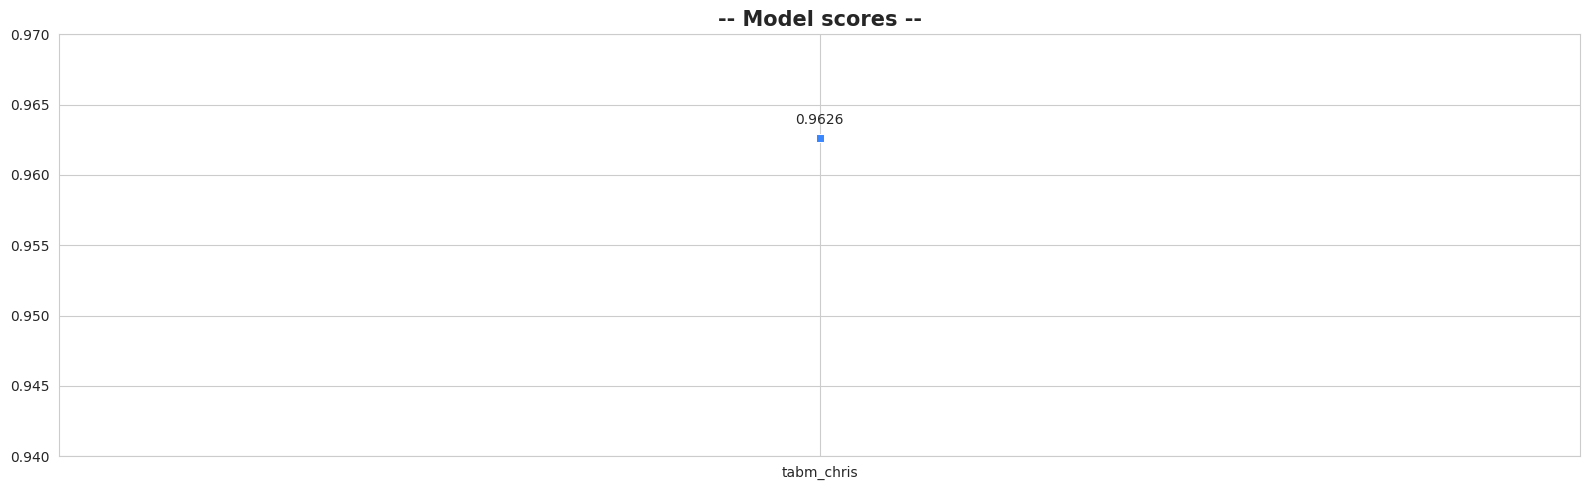

In [24]:
all_scores = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, z in v.items():
        if x == 'scores':
            all_scores[k] = z

raw_scores, calib_scores, names = [], [], []

if USE_CALIBRATION:
    for k, g in all_scores.items():
        raw_scores.append(g[0])
        calib_scores.append(g[1])
        names.append(k)
    
    plt.figure(figsize=(16, 5))
    ax1 = sns.lineplot(raw_scores, marker='s', label='base_model')
    ax2 = sns.lineplot(calib_scores, marker='o', label='calib_model')
    
    y_add = 4e-4
    
    for i, s1 in enumerate(raw_scores):
        ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='b')
    
    for i, s2 in enumerate(calib_scores):
        ax2.text(float(i), s2+y_add, s2, ha='center', va='baseline', color='r')
    
    # plt.legend(loc='best')
    # plt.ylim((0.94, 0.97))
    # plt.xticks(range(len(names)), names, rotation=0)
    # plt.title('Base vs Calibrated', fontdict={'weight': 'semibold', 'size': 15})
    # plt.tight_layout() 
    # plt.show()
else:
    plt.figure(figsize=(16, 5))
    ax1 = sns.lineplot([*all_scores.values()], marker='s')
    
    for i, s in enumerate([*all_scores.values()]):
        ax1.text(float(i), s+1e-3, s, ha='center', va='baseline')
    
plt.ylim((0.94, 0.97))
plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=0)
plt.title('-- Model scores --', fontdict={'weight': 'semibold', 'size': 15})
plt.tight_layout()
plt.show()

## Evaluation and Submission

In [25]:
## -- Get OOF predictions --

if USE_CALIBRATION:
    for i, (k, v) in enumerate(all_predictions.items()):
        for x, y in v.items():
            if x == "oof_preds":
                n = f"{k}_pytab_calib_{str(calib_scores[i]).split('.')[1]}"
                np.save(f"oof_{n}_.npy", y[1])
                print(f"oof file {n} saved!")
                print()
else:
    for i, (k, v) in enumerate(all_predictions.items()):
        for x, y in v.items():
            if x == "oof_preds":
                n = f"{k}_pytab_{str([*all_scores.values()][i]).split('.')[1]}"
                np.save(f"oof_{n}_.npy", y)
                print(f"oof file {n} saved!")

oof file tabm_chris_pytab_9626 saved!


Submission tabm_chris_pytab_9626 test saved! (247435,)


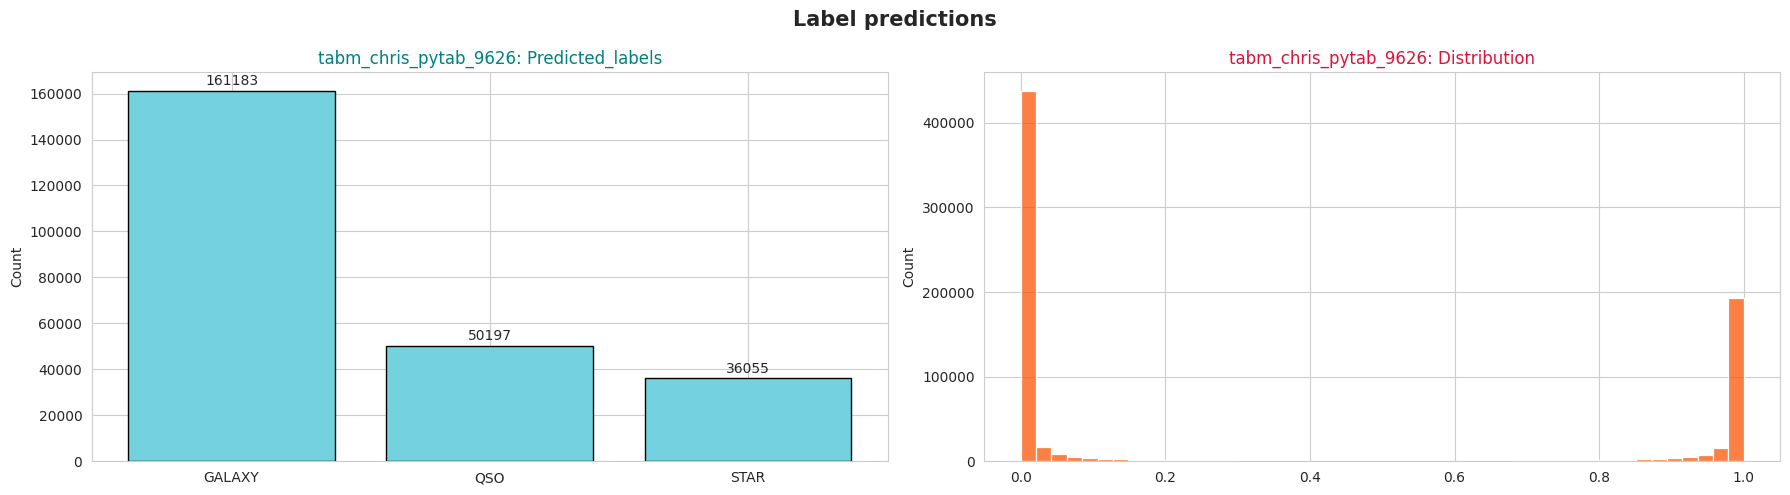

In [26]:
## -- Get TEST predictions --

final_test_results = {}
class_names = [*mapping.keys()]

if USE_CALIBRATION:
    for i, (k, v) in enumerate(all_predictions.items()):
        for x, p in v.items():
            if x == "test_preds":
                ## -- Base submission --
                n = f"{k}_pytab_{str(raw_scores[i]).split('.')[1]}"
                # np.save(f"test_pytab_{n}_.npy", p[0])

                base_preds = np.argmax(p[0], axis=1)
                # submit[TARGET] = pd.Series(base_preds).map(r_mapping)
                # submit.to_csv(f"submit_{n}.csv", index=False)
                # print(f"Submission base {n} test saved! {base_preds.shape}")

                ## -- Calib submission --
                cal_n = f"{k}_pytab_calib_{str(calib_scores[i]).split('.')[1]}"
                np.save(f"test_{cal_n}_.npy", p[1])

                calib_preds = np.argmax(p[1], axis=1)
                submit[TARGET] = pd.Series(calib_preds).map(r_mapping)
                submit.to_csv(f"submit_{cal_n}.csv", index=False)
                print(f"Submission {cal_n} test saved! {calib_preds.shape}")
                final_test_results[cal_n] = submit[TARGET]
                
                ## -- Distribution plots --
                fig, axes = plt.subplots(1, 2, figsize=(16, 5))
                for i, (ax, preds, title, color) in enumerate([
                    (axes[0], base_preds, f"Base model: {n}", "#73D2DE"),
                    (axes[1], calib_preds, f"Calibrated: {cal_n}", "#FB5607"),
                ]):
                    counts = [np.sum(preds == i) for i in range(len(np.unique(base_preds)))]
                    ax.bar(class_names, counts, color=color, edgecolor="k")
                    ax.set_title(title, color=["teal", "crimson"][i])
                    ax.set_ylabel("Count")
                
                    for i, c in enumerate(counts):
                        ax.text(i, c+2000, str(c), ha="center", fontsize=10)
                
                plt.suptitle("Distribution: Base vs Calibrated", fontsize=15, fontweight="semibold")
                plt.tight_layout()
                plt.show()
else:
    for i, (k, v) in enumerate(all_predictions.items()):
        for x, p in v.items():
            if x == "test_preds":
                n = f"{k}_pytab_{str([*all_scores.values()][i]).split('.')[1]}"
                np.save(f"test_{n}_.npy", p) 

                base_preds = np.argmax(p, axis=1)
                submit[TARGET] = pd.Series(base_preds).map(r_mapping)
                submit.to_csv(f"submit_{n}.csv", index=False)
                print(f"Submission {n} test saved! {base_preds.shape}")
                final_test_results[n] = submit[TARGET]

                ## -- Distribution plots --
                counts = [np.sum(base_preds == _) for _ in range(len(np.unique(base_preds)))]

                fig, axs = plt.subplots(1, 2, figsize=(18, 5))
                axs[0].bar(class_names, counts, color="#73D2DE", edgecolor="k")
                axs[0].set_title(f"{n}: Predicted_labels", color="teal")
                axs[0].set_ylabel("Count")
            
                for i, c in enumerate(counts):
                    axs[0].text(i, c+2500, str(c), ha="center", fontsize=10)
            
                sns.histplot(p.ravel(), ax=axs[1], color="#FB5607")
                axs[1].set_title(f"{n}: Distribution", color="crimson")
            
                plt.suptitle("Label predictions", fontsize=15, fontweight="semibold")
                plt.tight_layout()
                plt.show()


In [27]:
pd.DataFrame(final_test_results)

,tabm_chris_pytab_9626
0,GALAXY
1,GALAXY
2,GALAXY
3,STAR
4,GALAXY
...,...
247430,QSO
247431,QSO
247432,GALAXY
247433,QSO


In [28]:
# ## -- Distribution plots of the last model --
# if USE_CALIBRATION:
#     class_names = [*mapping.keys()]

#     fig, axes = plt.subplots(1, 2, figsize=(16, 5))
#     for i, (ax, preds, title, color) in enumerate([
#         (axes[0], base_preds, f"Base model: {n}", "#73D2DE"),
#         (axes[1], calib_preds, f"Calibrated: {cal_n}", "#FB5607"),
#     ]):
#         counts = [np.sum(preds == i) for i in range(len(np.unique(base_preds)))]
#         ax.bar(class_names, counts, color=color, edgecolor="k")
#         ax.set_title(title, color=["teal", "crimson"][i])
#         ax.set_ylabel("Count")
    
#         for i, c in enumerate(counts):
#             ax.text(i, c+2000, str(c), ha="center", fontsize=10)
    
#     plt.suptitle("Distribution: Base vs Calibrated", fontsize=15, fontweight="semibold")
#     plt.tight_layout()
#     plt.show()
# else:
#     class_names = [*mapping.keys()]
#     counts = [np.sum(base_preds == _) for _ in range(len(np.unique(base_preds)))]

#     fig, axs = plt.subplots(1, 2, figsize=(18, 5))
#     axs[0].bar(class_names, counts, color="#73D2DE", edgecolor="k")
#     axs[0].set_title(f"{n}: Predicted_labels", color="teal")
#     axs[0].set_ylabel("Count")

#     for i, c in enumerate(counts):
#         axs[0].text(i, c+2500, str(c), ha="center", fontsize=10)

#     sns.histplot(p.ravel(), ax=axs[1], color="#FB5607")
#     axs[1].set_title(f"{n}: Distribution", color="crimson")

#     plt.suptitle("Label predictions", fontsize=15, fontweight="semibold")
#     plt.tight_layout()
#     plt.show()

In [29]:
# !rm -r /kaggle/working/